In [ ]:
"""
Implementation of Parallelized Extreme Learning Machine (P-ELM)
Target: Online Data Classification & DevOps Anomaly Detection

Author: Amanda Taheri
Based on the research paper:
Title: Parallelized Extreme Learning Machine for Online Data Classification
https://doi.org/10.1007/s10489-022-03308-7
Copyright (c) 2026. All rights reserved.

"""

In [12]:
# 1. Setup and Imports
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Add the src directory to path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import Phase 1 and Phase 2 models
from src.elm_base import ELMBase  # Random weights
from src.elm_svd import ELMSVD  # SVD-based weights

print("Phase 2 Environment Ready!")


Phase 2 Environment Ready!


In [13]:
# 2. Data Generation with High Overlap (The "Hard" Test)
def generate_complex_devops_data(n_samples=5000):
    np.random.seed(42)
    
    # Normal: Mean is 50
    normal = np.random.normal(loc=50, scale=15, size=(n_samples // 2, 4))
    # Anomaly: Mean is 55 (Very close to Normal!)
    anomaly = np.random.normal(loc=55, scale=15, size=(n_samples // 2, 4))
    
    X = np.vstack([normal, anomaly])
    y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return train_test_split(X_scaled, y, test_size=0.3, random_state=42)

X_train, X_test, y_train, y_test = generate_complex_devops_data()

print(f"Training on {X_train.shape[0]} samples with 4 DevOps features.")


Training on 3500 samples with 4 DevOps features.


In [14]:
# 3. Compare Base ELM vs SVD ELM
hidden_neurons = 30

# Training Phase 1: Base ELM
base_model = ELMBase(input_size=4, hidden_size=hidden_neurons)
base_model.fit(X_train, y_train)
base_preds = (base_model.predict(X_test) > 0.5).astype(int)
base_acc = accuracy_score(y_test, base_preds)

# Training Phase 2: SVD-ELM (The Paper's Method)
svd_model = ELMSVD(input_size=4, hidden_size=hidden_neurons)
svd_model.fit(X_train, y_train)
svd_preds = (svd_model.predict(X_test) > 0.5).astype(int)
svd_acc = accuracy_score(y_test, svd_preds)

print(f"Random Weight ELM Accuracy: {base_acc * 100:.2f}%")
print(f"SVD-Initialized ELM Accuracy: {svd_acc * 100:.2f}%")


Model fitted. Output weights shape: (30,)
Random Weight ELM Accuracy: 63.20%
SVD-Initialized ELM Accuracy: 63.67%


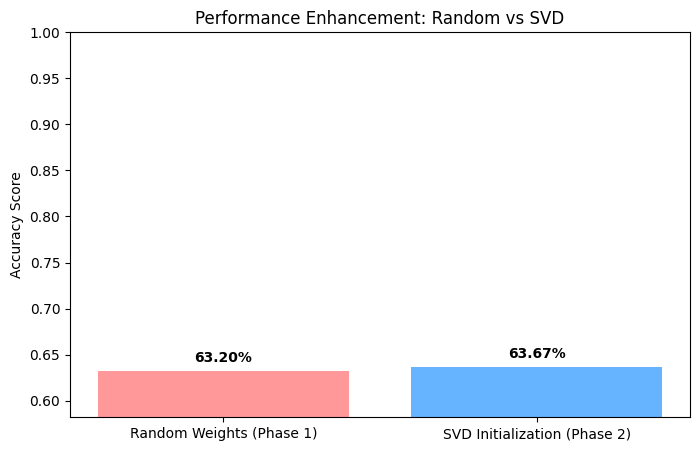

In [15]:
# 4. Visualize the comparison
methods = ['Random Weights (Phase 1)', 'SVD Initialization (Phase 2)']
accuracies = [base_acc, svd_acc]

plt.figure(figsize=(8, 5))
plt.bar(methods, accuracies, color=['#ff9999','#66b3ff'])
plt.ylabel('Accuracy Score')
plt.title('Performance Enhancement: Random vs SVD')
plt.ylim(min(accuracies) - 0.05, 1.0) # Zooming in for clarity

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v*100:.2f}%", ha='center', fontweight='bold')

plt.show()
